# **Libraries**

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# **1.  Data Understanding and Preprocessing**

## **1.Exploratory Data Analysis**

In [4]:
df = pd.read_csv("energy_data_set.csv")

In [5]:
df.shape

(19735, 29)

* **Dataset contains 19735 records and 28 Features**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

* **All variables are numeric data type.**

### setting index as date

In [7]:
df.index = df['date'].tolist()
df.drop(columns = "date", inplace =True)

### **1. Correlation plot**

<Axes: >

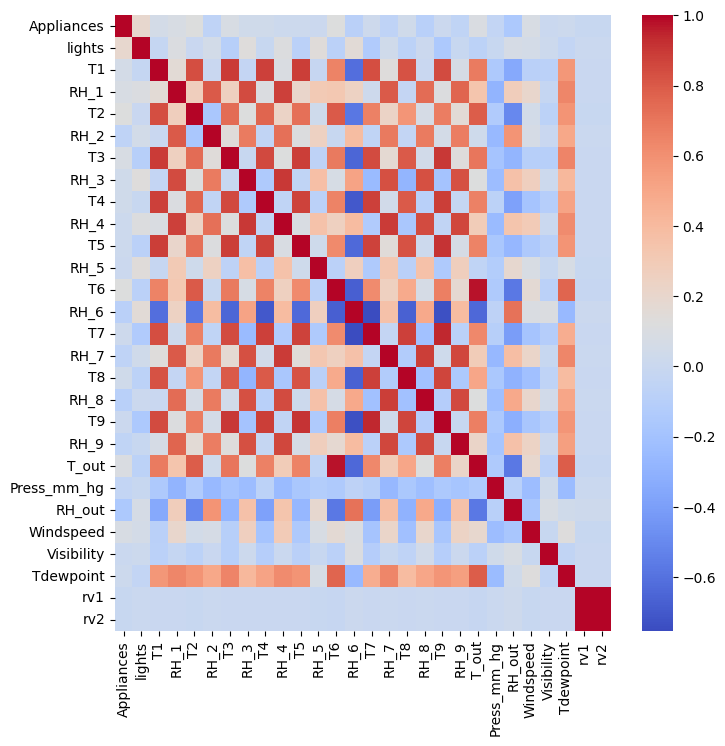

In [8]:
cor_data = df.corr()
plt.figure(figsize = [8,8])
sns.heatmap(cor_data, annot = False,cmap='coolwarm')

* **According to this correlation plot,**
  * **Appliances feature has low correlation values with other features.**
  * **We can see that there is a Multicollinearity in dataset.**

In [9]:
cor_data = pd.DataFrame(cor_data)['Appliances']
abs(cor_data).sort_values(ascending = False)

Appliances     1.000000
lights         0.197278
RH_out         0.152282
T2             0.120073
T6             0.117638
T_out          0.099155
RH_8           0.094039
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
RH_6           0.083178
RH_2           0.060465
RH_7           0.055642
T1             0.055447
RH_9           0.051462
T4             0.040281
T8             0.039572
RH_3           0.036292
Press_mm_hg    0.034885
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
rv1            0.011145
rv2            0.011145
T9             0.010010
RH_5           0.006955
Visibility     0.000230
Name: Appliances, dtype: float64

* **According to this dataframe, we can confirm that all variables have low correlation with Target variable.**

### **2. Seasonality of target variable**

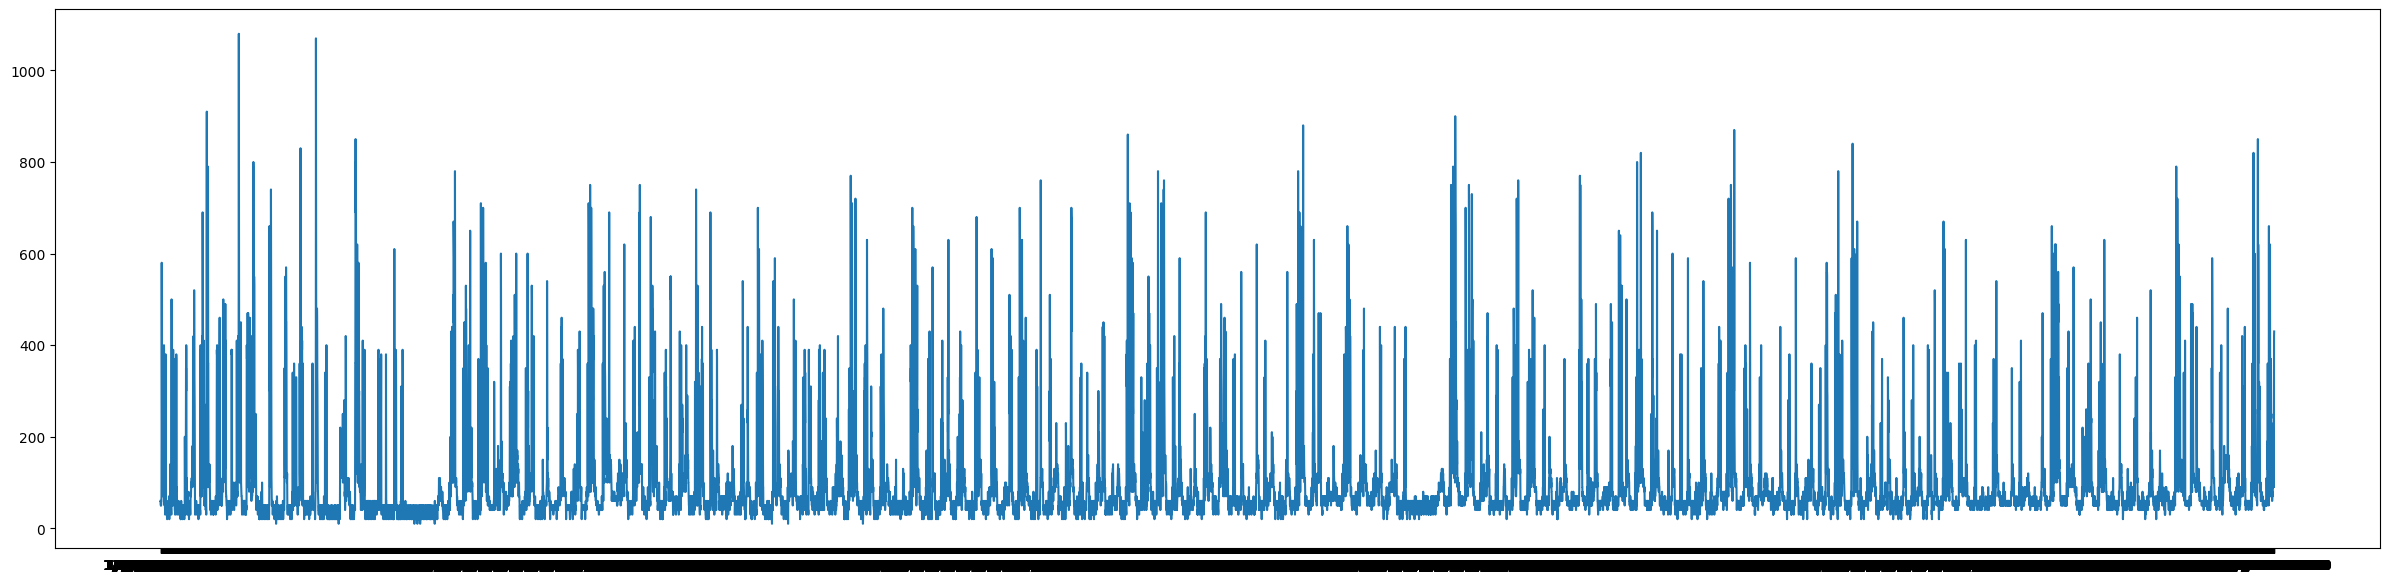

In [ ]:
plt.figure(figsize =[30,7])
plt.plot(df['Appliances'])
plt.show()

* **Using this plot, we can't get any information about variable 'Appliances'**

#### Setting date and time as index

In [10]:
df.index = pd.to_datetime(df.index)

* **Now, check whether what are the relationships between Appliances and hour/day/month**

#### Trend with pivot table

In [11]:
df['hour'] = df.index.hour
df['day'] = df.index.date
df['month'] = df.index.month

In [12]:
pivot1 = df.pivot_table(index = 'hour',values = 'Appliances')
pivot12 = df.pivot_table(index = 'hour',values = 'Appliances',columns = 'day')


#### **Energy consumption throughtout a day**

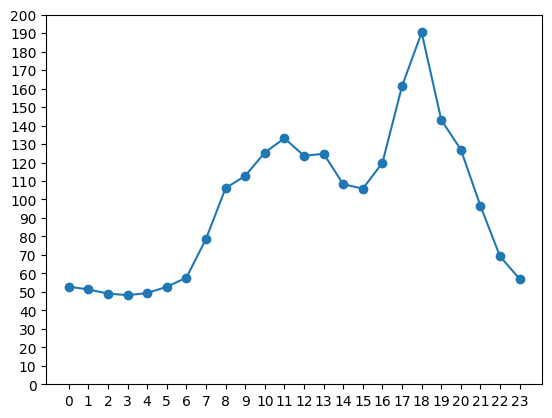

In [13]:
plt.plot(pivot1, marker = "o")
plt.xticks(range(0,24,1))
plt.yticks(range(0,210,10))
plt.show()

* **same as day life energy consumption**
  * **peak of energy comsumption is around 6.00 pm**
  * **low energy comsumption is from midnight to early morning**

#### **Energy consumption daywise plot**

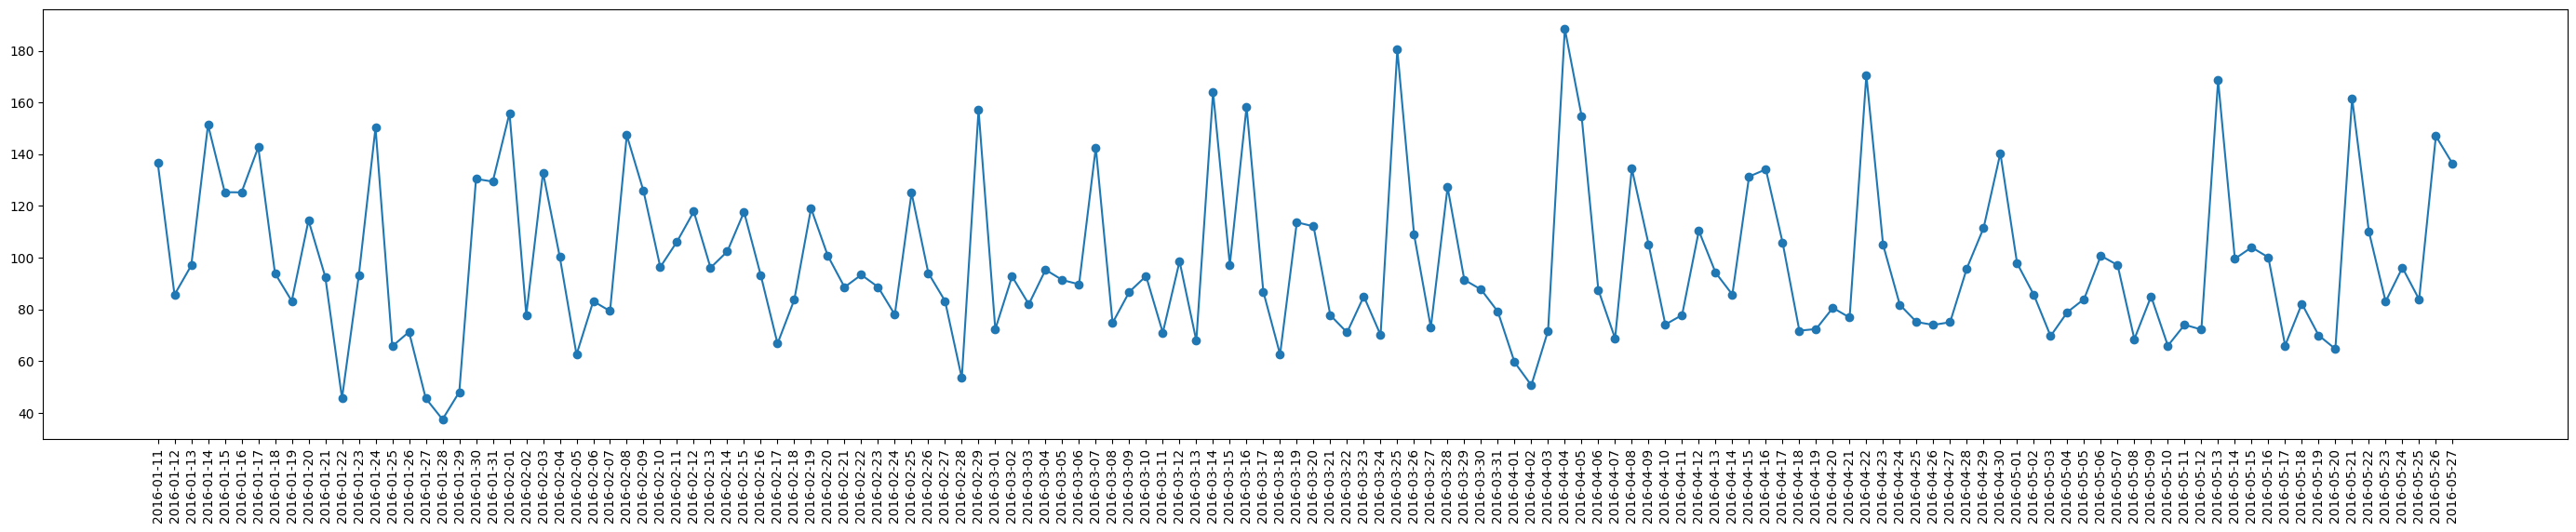

In [14]:
pivot2 = df.pivot_table(index = 'day',values = 'Appliances')
plt.figure(figsize=[35,6])
plt.plot(pivot2['Appliances'], marker = "o")
plt.xticks(pivot2.index,rotation = 90)
plt.show()

* There can some trend or seasonal flucuation.

**Time series decomposistion for energy consumption variables**

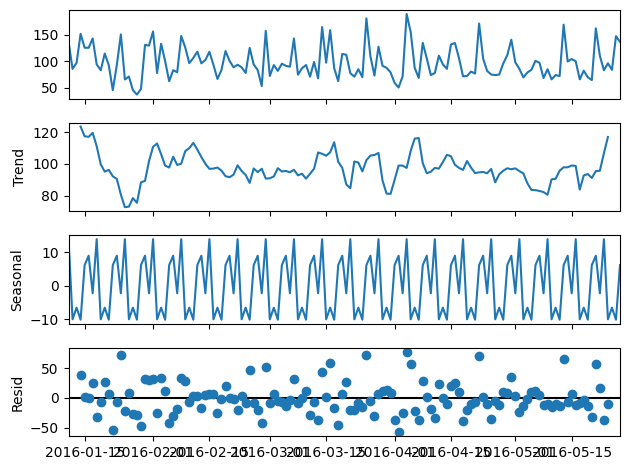

In [15]:
decomposition = seasonal_decompose(pivot2 , model='additive', period=7).plot()

* **There is a stable seasonality for week.**
* **No upword/downword trend in here.**

#### **Energy consumption in a week**

<Axes: xlabel='day1'>

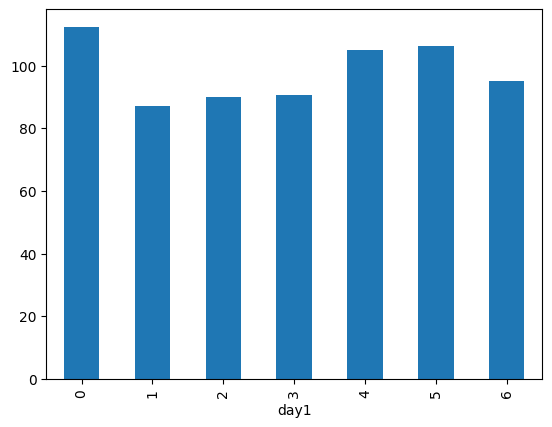

In [16]:
pivot2.index = pd.to_datetime(pivot2.index)
pivot2['day1'] = pivot2.index.dayofweek
pivot2.groupby('day1')['Appliances'].mean().plot(kind = 'bar')

* 0 is sunday when is the highest energy consumption
* 1 is Monday when is the lowest energy consumption

#### **Energy consumption month-wise plot**

In [17]:
pivot3 = df.pivot_table(index = 'month',values = 'Appliances')
pivot3

,Appliances
month,
1,97.026010
2,100.945881
3,96.953405
4,98.888889
5,94.199325


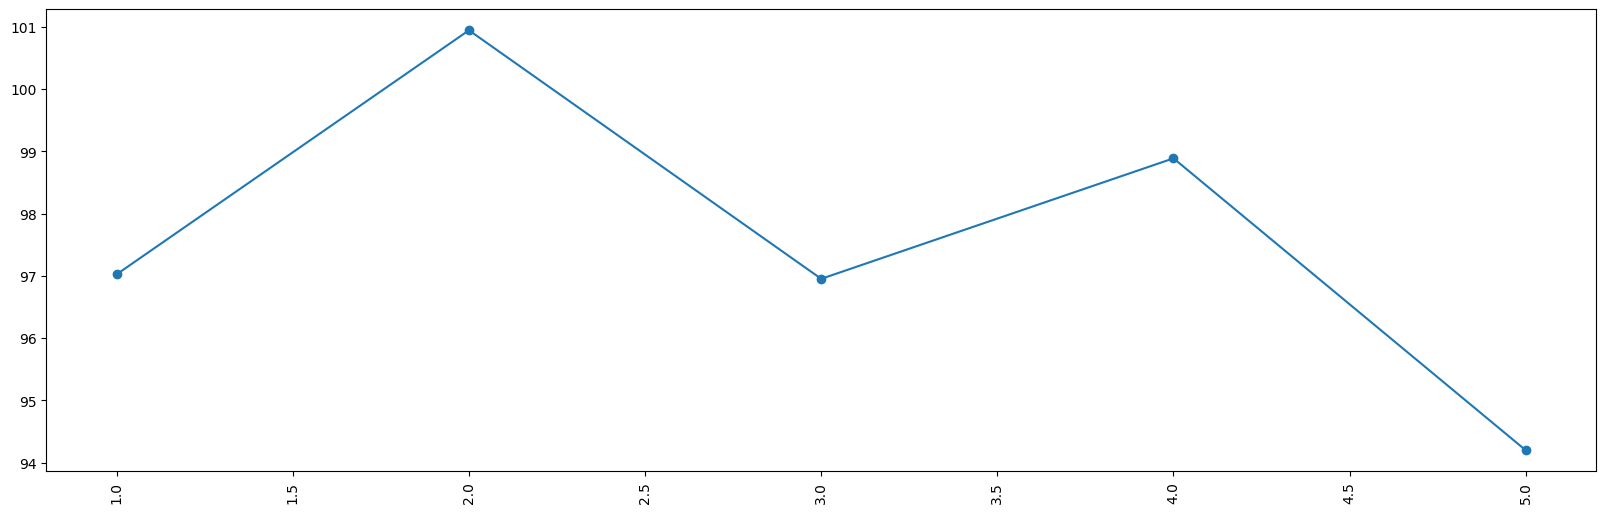

In [18]:

plt.figure(figsize=[20,6])
plt.plot(pivot3['Appliances'], marker = "o")
plt.xticks(rotation = 90)
plt.show()


* There are no meaningfull data.

# **Other Features**

Histogram of each variables

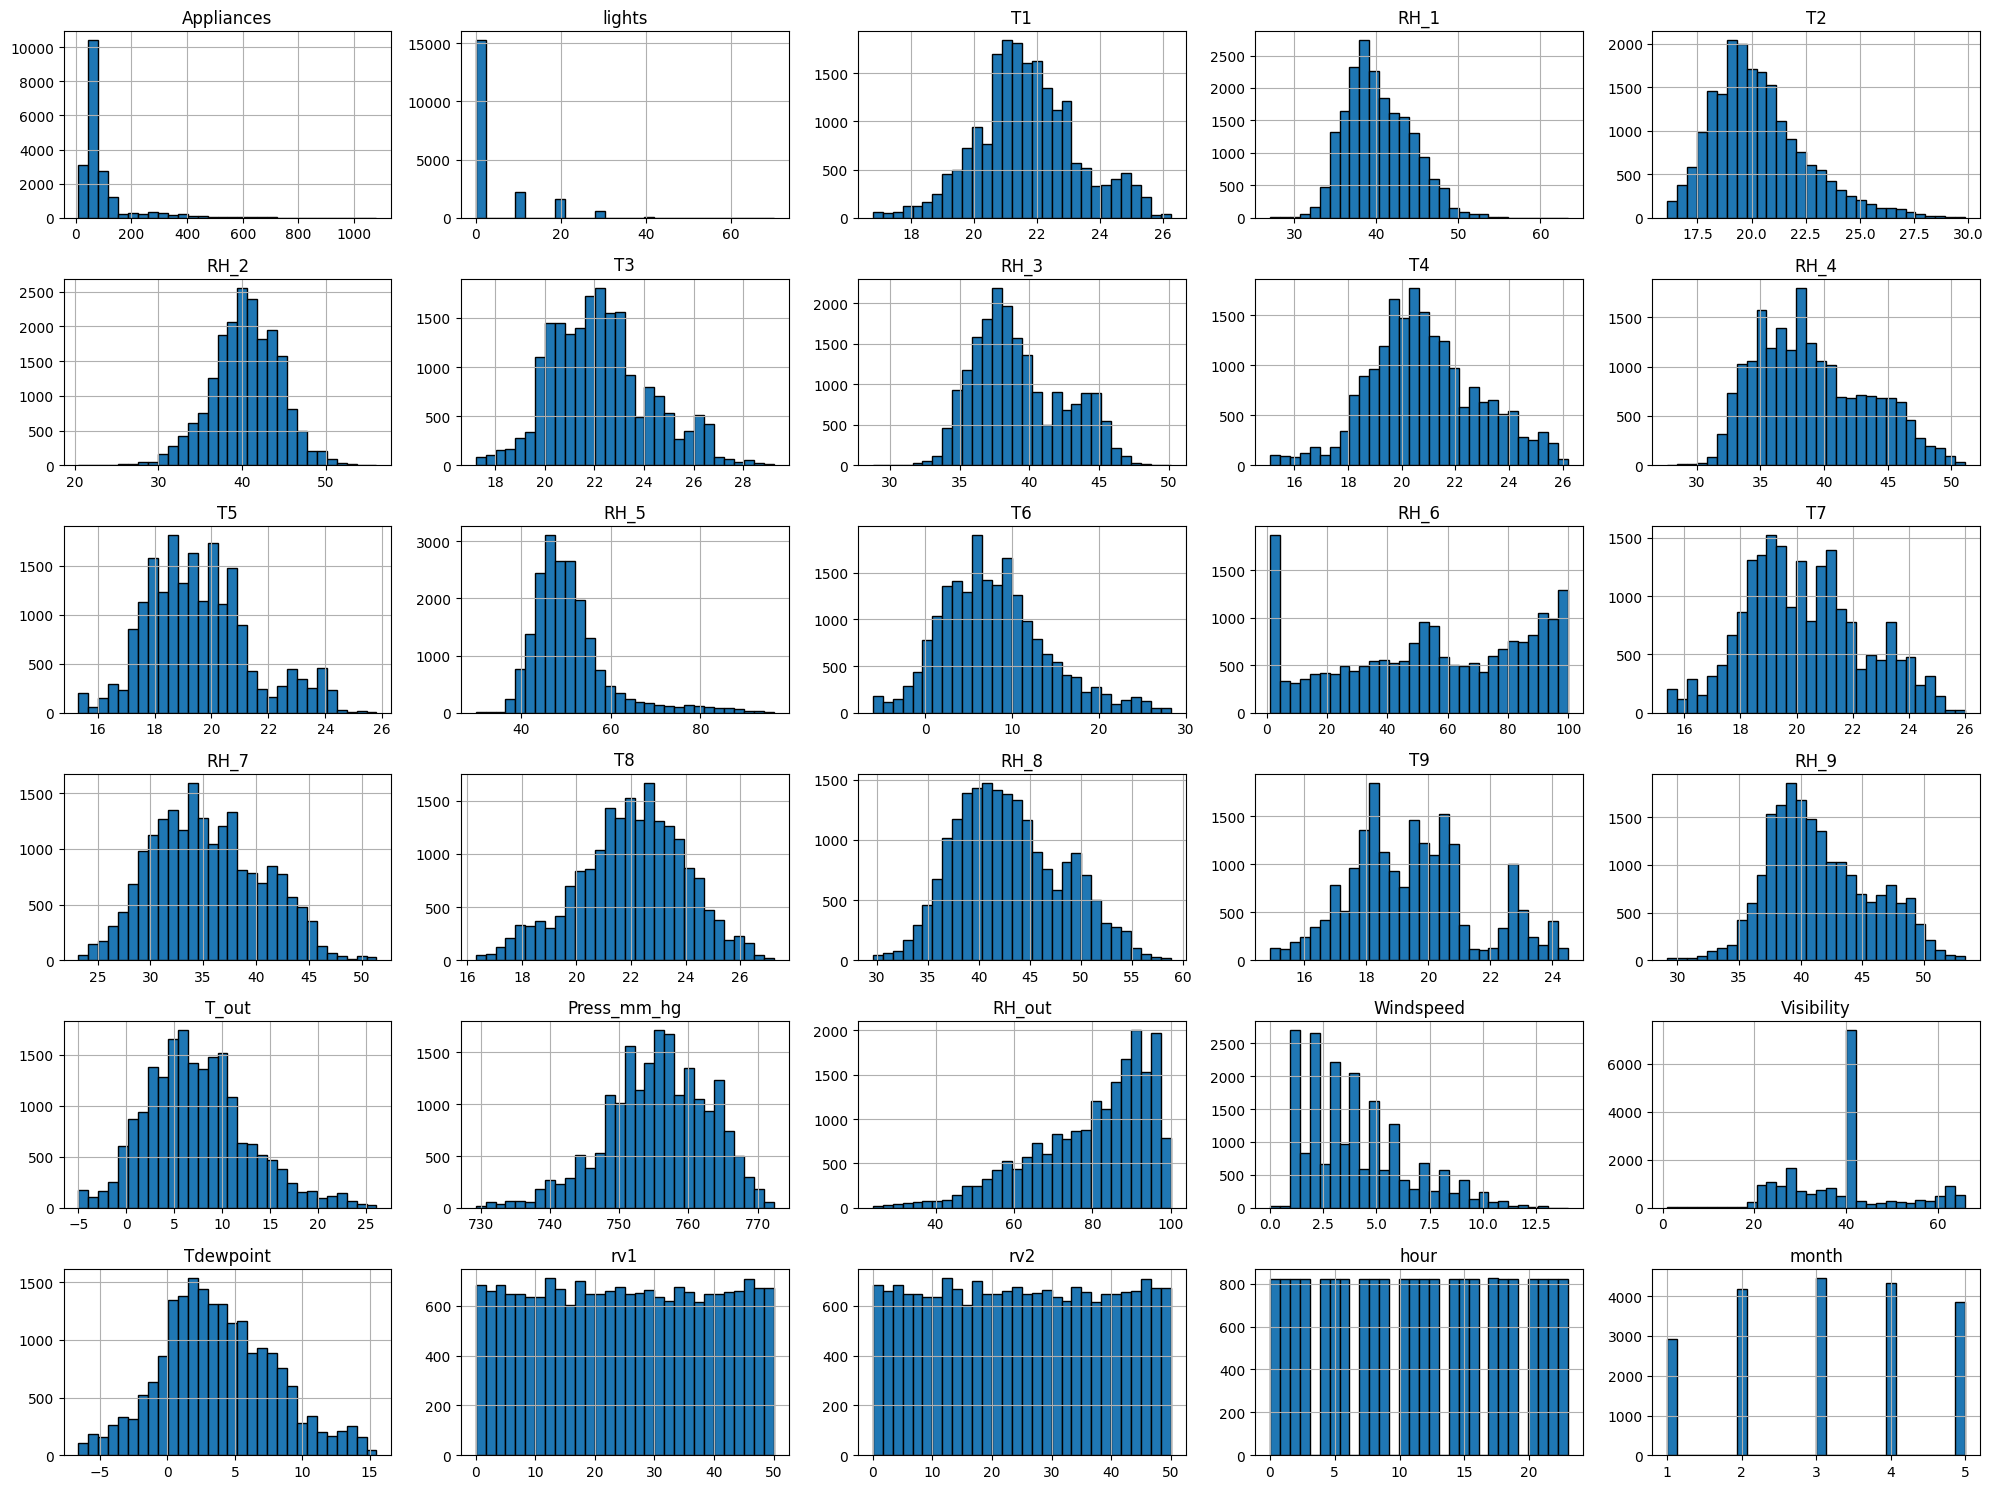

In [19]:
df.hist(
    bins=30,
    figsize=(20, 15),
    layout=(6, 5),
    edgecolor='black'
)

plt.tight_layout()
plt.show()

* According this plot, most of varibles are normally distributed, Also contains righj squness and right squness plots.
* final two variable which is high correlated with each other has same type of data distribution.